In [11]:
import pandas as pd

In [12]:
import matplotlib.pyplot as plt

In [13]:
import seaborn as sns

In [14]:
from scipy.stats import zscore

In [17]:
df = pd.read_csv('benin-malanville.csv')       

In [18]:
import os


In [19]:
if os.path.exists('data'):
    print("Contents of 'data/' folder:")
    print(os.listdir('data'))  # Lists all files in 'data/' folder
else:
    print("'data/' folder not found in the current directory.")

Contents of 'data/' folder:
['benin_clean.csv', 'sierra_leone_clean.csv', 'togo_clean.csv']


In [20]:
print(df.describe())

                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      240.559452     167.187516     115.358961     236.589496   
std       331.131327     261.710501     158.691074     326.894859   
min       -12.900000      -7.800000     -12.600000       0.000000   
25%        -2.000000      -0.500000      -2.100000       0.000000   
50%         1.800000      -0.100000       1.600000       4.500000   
75%       483.400000     314.200000     216.300000     463.700000   
max      1413.000000     952.300000     759.200000    1342.300000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      228.883576      28.179683      54.487969       2.121113   
std       316.536515       5.924297      28.073069       1.603466   
min         0.000000      11.000000       2.100000       0.000000   
25%         0.000000      24.2000

In [21]:
print(df.isna().sum())

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64


In [22]:
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

In [30]:
df[cols] = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [31]:
outliers = df[(df[cols].abs() > 3).any(axis=1)]

In [32]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [33]:
import os

In [34]:
os.makedirs('data', exist_ok=True)

In [35]:
df.to_csv('data/benin_clean.csv', index=False)

In [37]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

<Axes: xlabel='Timestamp'>

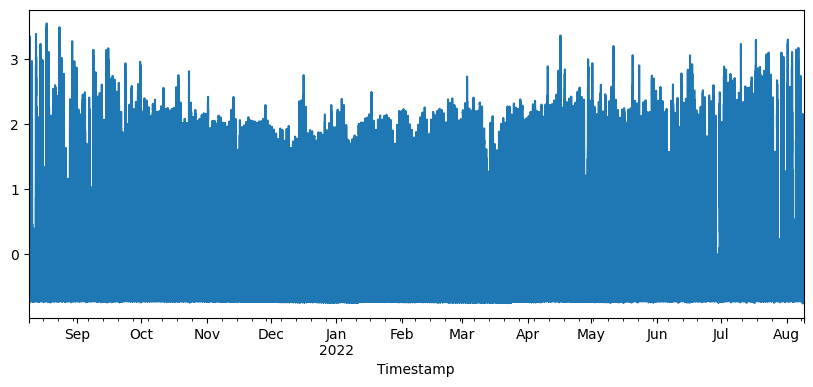

In [39]:
df.set_index('Timestamp')['GHI'].plot(figsize=(10, 4))

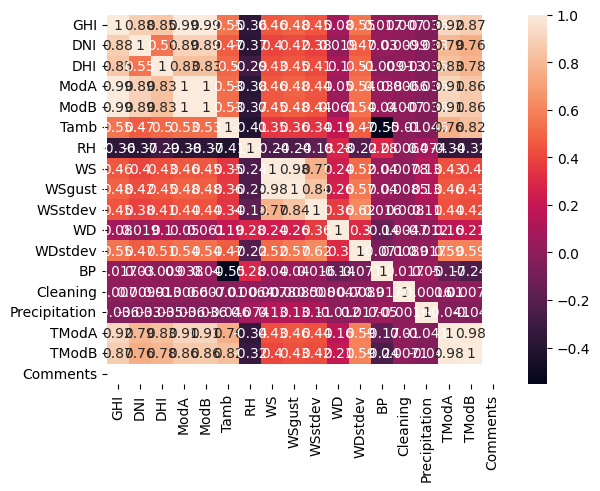

In [41]:
sns.heatmap(df.corr(numeric_only=True), annot=True); plt.show()